## Importing Libraries

In [2]:
import pandas as pd
import statsmodels.formula.api as smf
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
%matplotlib inline

In [3]:
import warnings
warnings.filterwarnings('ignore')

## Downloading Live Data

In [5]:
aord = yf.download('^AORD')

[*********************100%***********************]  1 of 1 completed


In [6]:
aord.head()

Price,Close,High,Low,Open,Volume
Ticker,^AORD,^AORD,^AORD,^AORD,^AORD
Date,,,,,
1984-08-03,713.000000,718.000000,706.200012,706.200012,0
1984-08-06,736.799988,736.799988,714.900024,714.900024,0
1984-08-07,728.500000,736.799988,728.000000,736.799988,0
1984-08-08,728.500000,730.799988,724.500000,728.000000,0
1984-08-15,735.099976,735.099976,726.799988,727.599976,0


In [7]:
nikkei = yf.download('^N225')
hsi = yf.download('^HSI')
cac40 = yf.download('^FCHI')
daxi = yf.download('^GDAXI')
sp500 = yf.download('^GSPC')
nasdaq = yf.download('^IXIC')
spy = yf.download('SPY')
dji = yf.download('DJI')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


## Feature Engineering

In [9]:
indicepanel = pd.DataFrame(index=spy.index)

In [10]:
#Creating an indicepanel with spy as an index
#US markets
indicepanel['spy'] = spy['Open'].shift(-1)-spy['Open']
indicepanel['spy_lag1'] = indicepanel['spy'].shift(1)
indicepanel['sp500'] = sp500['Open'] - sp500['Open'].shift(1)
indicepanel['nasdaq'] = nasdaq['Open']-nasdaq['Open'].shift(1)
indicepanel['dji'] = dji['Open']-dji['Open'].shift(1)

#EU markets
indicepanel['cac40'] = cac40['Open'] - cac40['Open'].shift(1)
indicepanel['daxi'] = daxi['Open'] - daxi['Open'].shift(1)

#Asian markets
indicepanel['aord'] = aord['Close']-aord['Open']
indicepanel['hsi'] = hsi['Close'] - hsi['Open']
indicepanel['nikkei'] = nikkei['Close'] - nikkei['Open']
indicepanel['Price'] = spy['Open']

In [11]:
indicepanel.head()

,spy,spy_lag1,sp500,nasdaq,dji,cac40,daxi,aord,hsi,nikkei,Price
Date,,,,,,,,,,,
1993-01-29,1.015280e-05,NaN,0.540009,1.570007,3.780029,26.500000,1.359985,1.500000,-34.100098,-52.570312,24.330317
1993-02-01,1.383321e-01,0.000010,0.109985,1.019958,22.149902,-17.699951,16.289917,0.900024,-45.500000,96.121094,24.330327
1993-02-02,1.037493e-01,0.138332,3.739990,4.270020,-3.510010,32.299927,-6.189941,-0.300049,-30.799805,39.630859,24.468659
1993-02-03,3.112735e-01,0.103749,0.040009,5.429993,45.120117,-1.299927,21.770020,0.000000,48.299805,-4.521484,24.572408
1993-02-04,3.205405e-07,0.311274,4.640015,2.350037,42.949951,37.399902,10.069946,-0.199951,54.500000,-82.769531,24.883682


In [12]:
indicepanel.isnull().sum()

spy            1
spy_lag1       1
sp500          0
nasdaq         0
dji         1068
cac40        125
daxi         153
aord         171
hsi          369
nikkei       474
Price          0
dtype: int64

In [13]:
indicepanel = indicepanel.fillna(method='ffill')
indicepanel = indicepanel.dropna()

In [14]:
indicepanel.isnull().sum()

spy         0
spy_lag1    0
sp500       0
nasdaq      0
dji         0
cac40       0
daxi        0
aord        0
hsi         0
nikkei      0
Price       0
dtype: int64

In [15]:
print(indicepanel.shape)

(8221, 11)


In [16]:
train = indicepanel.iloc[-8000:-4000,:]
test = indicepanel.iloc[-4000:,:]
print(train.shape, test.shape)

(4000, 11) (4000, 11)


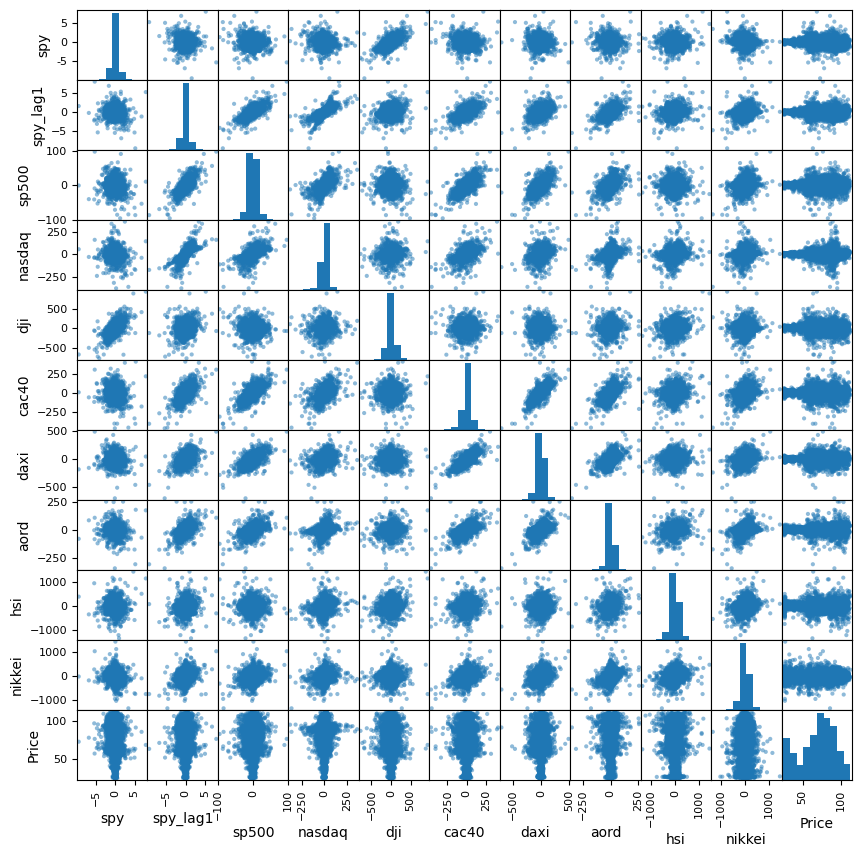

In [17]:
from pandas.plotting import scatter_matrix

sm = scatter_matrix(train, figsize=(10,10))
plt.show()

In [18]:
corr_array = train.iloc[:,:-1].corr()['spy']
print(corr_array)

spy         1.000000
spy_lag1   -0.083166
sp500      -0.074279
nasdaq     -0.082614
dji         0.670184
cac40      -0.066537
daxi       -0.043270
aord       -0.045752
hsi         0.030590
nikkei     -0.069717
Name: spy, dtype: float64


## Machine Learning Model

In [19]:
formula = 'spy~spy_lag1+sp500+nasdaq+dji+cac40+daxi+aord+hsi+nikkei'
lm = smf.ols(formula=formula, data=train).fit()
lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    spy   R-squared:                       0.566
Model:                            OLS   Adj. R-squared:                  0.565
Method:                 Least Squares   F-statistic:                     577.2
Date:                Sat, 27 Sep 2025   Prob (F-statistic):               0.00
Time:                        16:13:37   Log-Likelihood:                -3723.3
No. Observations:                4000   AIC:                             7467.
Df Residuals:                    3990   BIC:                             7529.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0042      0.010      0.436      0.663      -0.015       0.023
spy_lag1      -0.5211      0.021    -24.460      0.000      -0.563      -0.479
sp500          0.0298      0.001     20.715      0.000       0.027       0.033
nasdaq         0.0004      0.000      0.975      0.330      -0.000       0.001
dji            0.0068   9.62e-05     71.174      0.000       0.007       0.007
cac40          0.0002      0.000      0.601      0.548      -0.000       0.001
daxi          -0.0013      0.000     -5.433      0.000      -0.002      -0.001
aord          -0.0006      0.000     -1.630      0.103      -0.001       0.000
hsi        -7.472e-05   5.61e-05     -1.332      0.183      -0.000    3.53e-05
nikkei        -0.0003   5.76e-05     -5.910      0.000      -0.000      -0.000
==============================================================================
Omnibus:                      707.798   Durbin-Watson:                   2.240
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            13660.642
Skew:                          -0.253   Prob(JB):                         0.00
Kurtosis:                      12.039   Cond. No.                         465.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [20]:
train['PredictedY'] = lm.predict(train)
test['PredictedY'] = lm.predict(test)

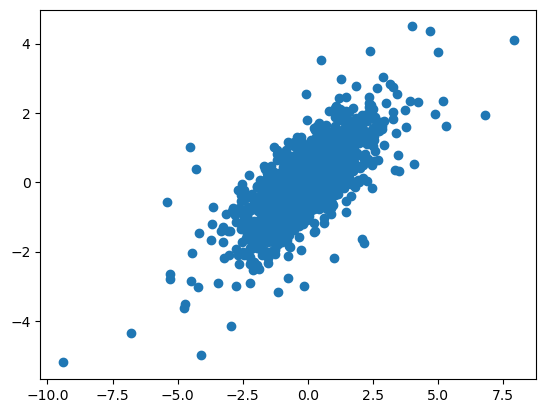

In [21]:
plt.scatter(train['spy'], train['PredictedY'])
plt.show()

In [22]:
def adjustedMetric(data, model, model_k, yname):
    data['yhat'] = model.predict(data)
    SST = ((data[yname] - data[yname].mean())**2).sum()
    SSR = ((data['yhat'] - data[yname].mean())**2).sum()
    SSE = ((data[yname] - data['yhat'])**2).sum()
    r2 = SSR/SST
    adjustR2 = 1 - (1-r2)*(data.shape[0] - 1)/(data.shape[0] - model_k - 1)
    RMSE = (SSE / (data.shape[0] - model_k - 1))**0.5
    return adjustR2, RMSE

In [23]:
def assessTable(test, train, model, model_k, yname):
    r2test, RMSEtest = adjustedMetric(test, model, model_k, yname)
    r2train, RMSEtrain = adjustedMetric(train, model, model_k, yname)
    assessment = pd.DataFrame(index=['R2', 'RMSE'], columns=['Train', 'Test'])
    assessment['Train'] = [r2train, RMSEtrain]
    assessment['Test'] = [r2test, RMSEtest]
    return assessment

In [24]:
assessTable(test, train, lm, 9, 'spy')

,Train,Test
R2,0.564621,0.533924
RMSE,0.614548,3.574465


## Signal based strategy backtesting and Data visualization

In [26]:
train['Order'] = [1 if sig>0 else -1 for sig in train['PredictedY']]
train['Profit'] = train['spy']*train['Order']

train['Wealth'] = train['Profit'].cumsum()
print('Total profit made in train: ', train['Profit'].sum())

Total profit made in train:  1823.0080631968247


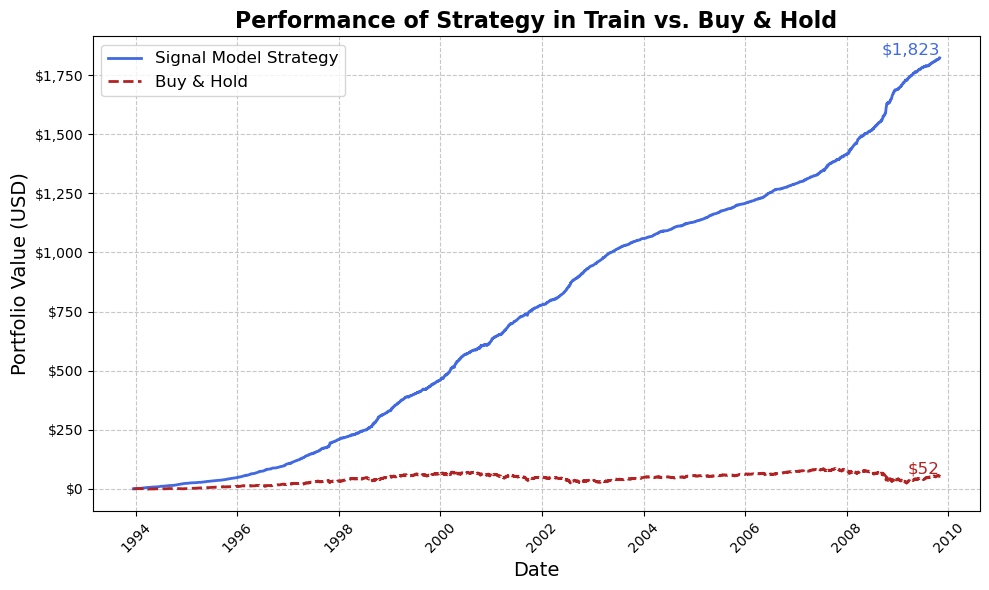

In [27]:
import matplotlib.ticker as mtick

plt.figure(figsize=(10,6))

plt.title('Performance of Strategy in Train vs. Buy & Hold', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Portfolio Value (USD)', fontsize=14)
plt.gca().yaxis.set_major_formatter('${x:,.0f}')


plt.plot(train.index, train['Wealth'].values, color='royalblue', linewidth=2, label='Signal Model Strategy')
plt.plot(train.index, train['spy'].cumsum().values, color='firebrick', linestyle='--', linewidth=2, label='Buy & Hold')

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12, loc='upper left', frameon=True)

plt.text(train.index[-1], train['Wealth'].values[-1],
         f"${train['Wealth'].values[-1]:,.0f}",  
         color='royalblue', fontsize=12, va='bottom', ha='right')

plt.text(train.index[-1], train['spy'].cumsum().values[-1],
         f"${train['spy'].cumsum().values[-1]:,.0f}",
         color='firebrick', fontsize=12, va='bottom', ha='right')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
test['Order'] = [1 if sig>0 else -1 for sig in test['PredictedY']]
test['Profit'] = test['spy']*test['Order']

test['Wealth'] = test['Profit'].cumsum()
print('Total profit made in train: ', test['Profit'].sum())

Total profit made in train:  2621.541588896568


In [29]:
model_return_test = (test['Wealth'].values[-1] / test['Wealth'].values[0] - 1) * 100
buyhold_return = (test['spy'].cumsum().values[-1] / test['spy'].cumsum().values[0] - 1) * 100

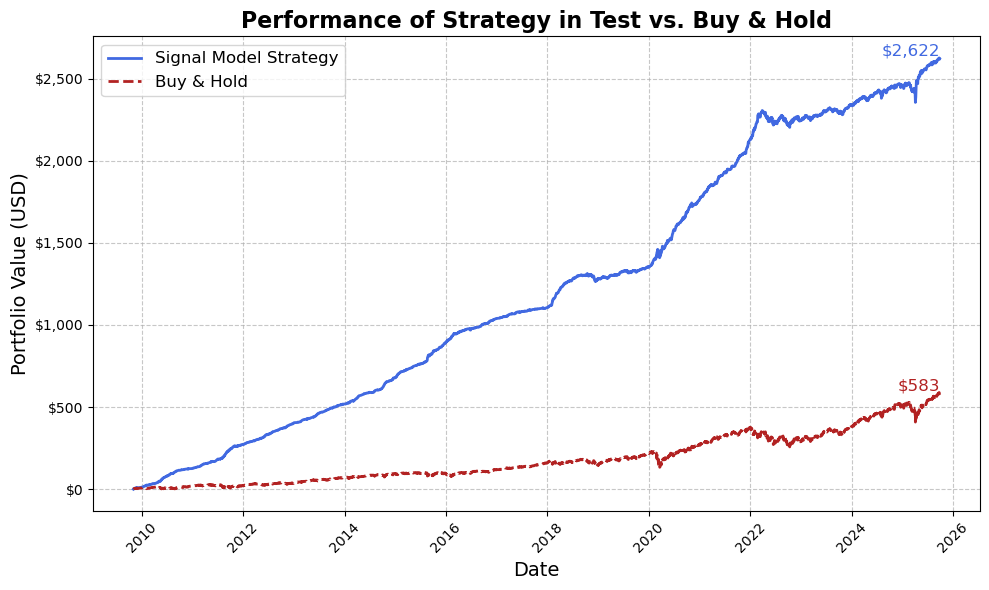

In [30]:
plt.figure(figsize=(10,6))

plt.title('Performance of Strategy in Test vs. Buy & Hold', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Portfolio Value (USD)', fontsize=14)
plt.gca().yaxis.set_major_formatter('${x:,.0f}')


plt.plot(test.index, test['Wealth'].values, color='royalblue', linewidth=2, label='Signal Model Strategy')
plt.plot(test.index, test['spy'].cumsum().values, color='firebrick', linestyle='--', linewidth=2, label='Buy & Hold')

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12, loc='upper left', frameon=True)

plt.text(test.index[-1], test['Wealth'].values[-1],
         f"${test['Wealth'].values[-1]:,.0f}",  
         color='royalblue', fontsize=12, va='bottom', ha='right')

plt.text(test.index[-1], test['spy'].cumsum().values[-1],
         f"${test['spy'].cumsum().values[-1]:,.0f}",
         color='firebrick', fontsize=12, va='bottom', ha='right')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Model Evaluation - Sharpe Ratio and Maximum Drawdown

In [32]:
train['Wealth'] = train['Wealth'] + train.loc[train.index[0], 'Price']
test['Wealth'] = test['Wealth'] + test.loc[test.index[0], 'Price']

In [33]:
# Sharpe Ratio on Train data
train['Return'] = np.log(train['Wealth']) - np.log(train['Wealth'].shift(1))
daily_return_train = train['Return'].dropna()

print('Daily Sharpe Ratio is ', daily_return_train.mean()/daily_return_train.std(ddof=1))
print('Yearly Sharpe Ratio is ', (252**0.5)*daily_return_train.mean()/daily_return_train.std(ddof=1))

Daily Sharpe Ratio is  0.47914175382024116
Yearly Sharpe Ratio is  7.606139540134143


In [34]:
# Sharpe Ratio in Test data
test['Return'] = np.log(test['Wealth']) - np.log(test['Wealth'].shift(1))
daily_return_test = test['Return'].dropna()

print('Daily Sharpe Ratio is ', daily_return_test.mean()/daily_return_test.std(ddof=1))
print('Yearly Sharpe Ratio is ', (252**0.5)*daily_return_test.mean()/daily_return_test.std(ddof=1))

Daily Sharpe Ratio is  0.3277288961356141
Yearly Sharpe Ratio is  5.202534939747313


In [35]:
# Maximum Drawdown in Train data
train['Peak'] = train['Wealth'].cummax()
train['Drawdown'] = (train['Peak'] - train['Wealth'])/train['Peak']
print('Maximum Drawdown in Train is ', train['Drawdown'].max())

Maximum Drawdown in Train is  0.01983196915358533


In [36]:
# Maximum Drawdown in Test data
test['Peak'] = test['Wealth'].cummax()
test['Drawdown'] = (test['Peak'] - test['Wealth'])/test['Peak']
print('Maximum Drawdown in Test is ', test['Drawdown'].max())

Maximum Drawdown in Test is  0.046921467084267365


In [37]:
test_1y = test.iloc[-252:].copy()

In [38]:
test_1y['Order'] = [1 if sig > 0 else -1 for sig in test_1y['PredictedY']]
test_1y['Profit'] = test_1y['Order'] * test_1y['spy']
test_1y['Wealth'] = 1 + test_1y['Profit'].cumsum()
test_1y['BuyHold'] = 1 + test_1y['spy'].cumsum()

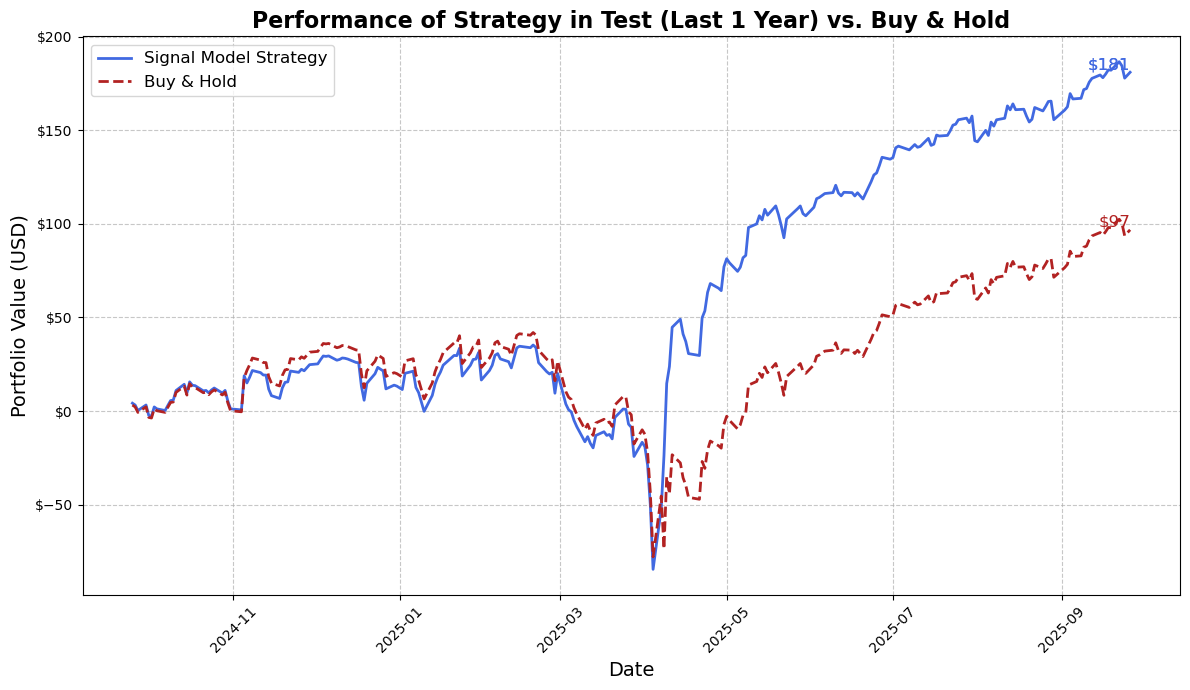

In [39]:
plt.figure(figsize=(12,7))
plt.title('Performance of Strategy in Test (Last 1 Year) vs. Buy & Hold', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Portfolio Value (USD)', fontsize=14)
plt.gca().yaxis.set_major_formatter('${x:,.0f}')

plt.plot(test_1y.index, test_1y['Wealth'].values, color='royalblue', linewidth=2, label='Signal Model Strategy')
plt.plot(test_1y.index, test_1y['spy'].cumsum().values, color='firebrick', linestyle='--', linewidth=2, label='Buy & Hold')

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12, loc='upper left', frameon=True)

plt.text(test_1y.index[-1], test_1y['Wealth'].values[-1],
         f"${test_1y['Wealth'].values[-1]:,.0f}",  
         color='royalblue', fontsize=12, va='bottom', ha='right')

plt.text(test_1y.index[-1], test_1y['spy'].cumsum().values[-1],
         f"${test_1y['spy'].cumsum().values[-1]:,.0f}",
         color='firebrick', fontsize=12, va='bottom', ha='right')

plt.text(test_1y.index[-1], test_1y['Wealth'].values[-1],
         f"${test_1y['Wealth'].values[-1]:,.0f}",
         color='royalblue', fontsize=12, va='bottom', ha='right')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()